# Week 09 — Home exercise 5: A figure per group, and a grid

**Solution proposal.**

Three ways of showing several groups at once. They are not interchangeable, and the last question is
the one that matters.

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt

co2 = pd.read_csv("../data/co2_emissions.csv")
info = pd.read_csv("../data/country_info.csv")

panel = co2.merge(info[["code", "region"]], on="code", how="left", validate="many_to_one")
panel = panel[panel["region"] != "Aggregates"].dropna(subset=["co2_total"])
panel["co2_pc"] = panel["co2_total"] * 1_000_000 / panel["population"]

regions = sorted(panel["region"].unique())
print(len(regions), "regions")

7 regions


## 1 and 2. One file per region

Two of the region names are awkward as file names: `"East Asia & Pacific"` contains an ampersand and
spaces, and `"Middle East, North Africa, Afghanistan & Pakistan"` adds commas and is 49 characters
long. None of those is illegal on every operating system, and all of them are a nuisance — spaces
force you to quote the name in a terminal, and `&` means something to the shell.

So build the file name rather than using the region name directly.

In [2]:
def to_file_name(region):
    """Turn a region name into a safe lower-case file name stem."""
    stem = region.lower()
    for bad, good in [(" & ", "-"), (", ", "-"), (" ", "-")]:
        stem = stem.replace(bad, good)
    return stem


for region in regions:
    print(f"{region:52s} -> plot-{to_file_name(region)}.png")

East Asia & Pacific                                  -> plot-east-asia-pacific.png
Europe & Central Asia                                -> plot-europe-central-asia.png
Latin America & Caribbean                            -> plot-latin-america-caribbean.png
Middle East, North Africa, Afghanistan & Pakistan    -> plot-middle-east-north-africa-afghanistan-pakistan.png
North America                                        -> plot-north-america.png
South Asia                                           -> plot-south-asia.png
Sub-Saharan Africa                                   -> plot-sub-saharan-africa.png


Now the loop that writes them. Watch the last line of it, `plt.close(fig)`, and watch what the cell
does *not* produce.

In [3]:
for region in regions:
    rows = panel[panel["region"] == region].groupby("year")["co2_total"].sum()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(rows.index, rows.values)

    ax.set_xlabel("Year")
    ax.set_ylabel("Total CO₂, million tonnes")
    ax.set_title(f"{region}: total CO₂ emissions")
    ax.set_ylim(0, None)
    ax.grid(True, alpha=0.3)

    fig.savefig(f"plot-{to_file_name(region)}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

written = sorted(name for name in os.listdir(".") if name.startswith("plot-"))
print(len(written), "files written:")
for name in written:
    print(" ", name)

7 files written:
  plot-east-asia-pacific.png
  plot-europe-central-asia.png
  plot-latin-america-caribbean.png
  plot-middle-east-north-africa-afghanistan-pakistan.png
  plot-north-america.png
  plot-south-asia.png
  plot-sub-saharan-africa.png


Seven files, and **no figures appeared in the notebook** — that is `plt.close(fig)` doing its job.

It is not a tidiness measure. Every figure you create stays in memory until it is closed, so a loop
over 200 countries builds 200 figures, matplotlib warns you after 20, and eventually the notebook slows
to a crawl. **A loop that saves figures should close them.** The rule only bites at scale, which is
exactly why it is worth learning on a loop of seven.

### If the names came from a file I did not control

`to_file_name` handles the three characters that happen to be in *this* file. That is fine here and it
is not a general solution — the next file will have a slash in a name, or an accent, or a colon, or two
regions whose names differ only by punctuation and collapse to the same file name.

For anything running unattended I would not build file names out of data at all. I would number them
(`plot-01.png`) and write a small table alongside saying which number is which region. The name then
cannot fail, and the mapping is in a file that can be read rather than in a string function that has to
be right.

## 3. A 2×2 grid, sharing the y-axis

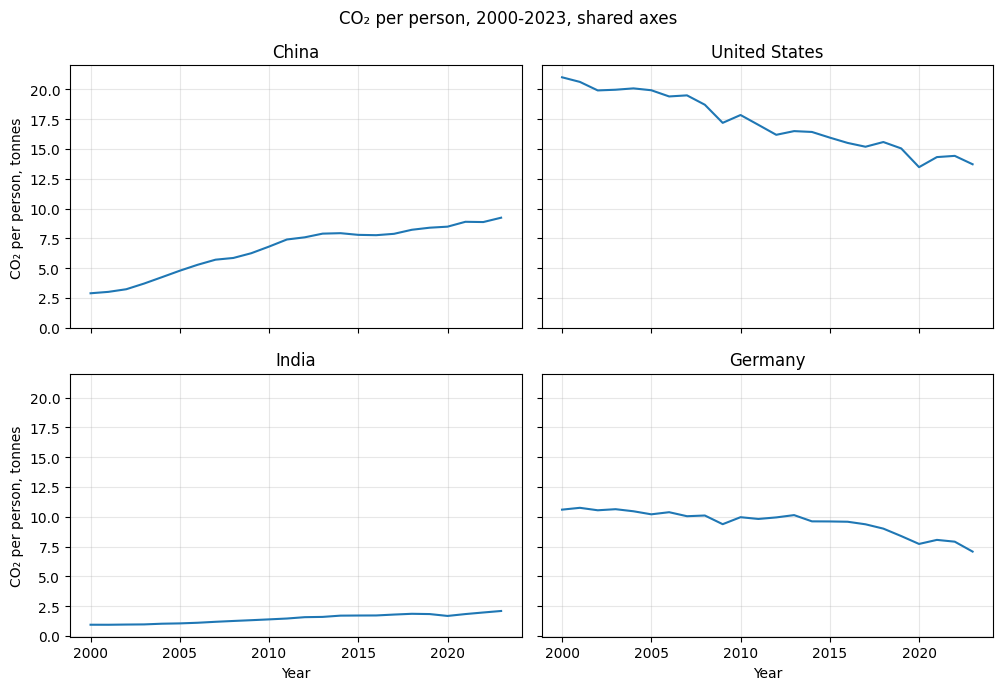

In [4]:
countries = ["China", "United States", "India", "Germany"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 7), sharex=True, sharey=True)

for ax, country in zip(axes.flatten(), countries):
    rows = panel[panel["country"] == country].sort_values("year")
    ax.plot(rows["year"], rows["co2_pc"])
    ax.set_title(country)
    ax.grid(True, alpha=0.3)

axes[0, 0].set_ylabel("CO₂ per person, tonnes")
axes[1, 0].set_ylabel("CO₂ per person, tonnes")
axes[1, 0].set_xlabel("Year")
axes[1, 1].set_xlabel("Year")

fig.suptitle("CO₂ per person, 2000-2023, shared axes")
fig.tight_layout();

## 4. The same grid, with independent axes

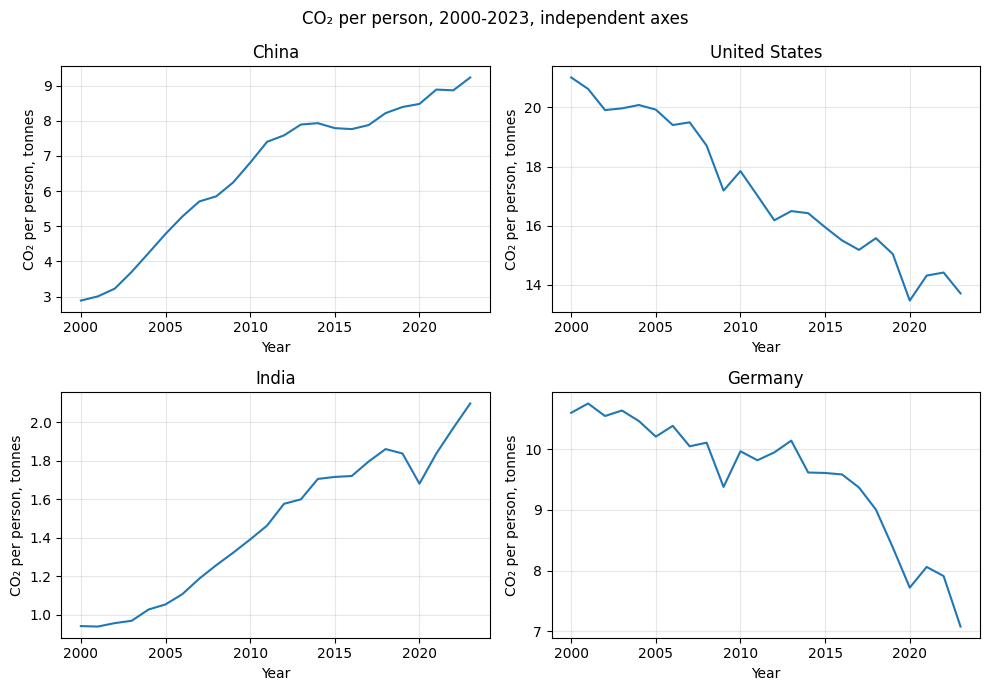

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 7))

for ax, country in zip(axes.flatten(), countries):
    rows = panel[panel["country"] == country].sort_values("year")
    ax.plot(rows["year"], rows["co2_pc"])
    ax.set_title(country)
    ax.set_xlabel("Year")
    ax.set_ylabel("CO₂ per person, tonnes")
    ax.grid(True, alpha=0.3)

fig.suptitle("CO₂ per person, 2000-2023, independent axes")
fig.tight_layout();

In [6]:
levels = panel[panel["country"].isin(countries) & (panel["year"] == 2023)]

levels[["country", "co2_pc"]].sort_values("co2_pc", ascending=False).round(2)

,country,co2_pc
5975,United States,13.71
1127,China,9.23
2111,Germany,7.08
2639,India,2.10


### What each version says

**Independent axes.** Four panels of roughly the same height, so all four countries look like they emit
roughly the same amount and differ only in direction: China up, the others down. India's panel is the
most dramatic of the four — a line climbing steeply across the whole figure.

**Shared axes.** India is a nearly flat line near the bottom at around 2 tonnes; the United States
towers over everything at 13.7; China rises to 9.2 and Germany falls to 7.1.

**The shared version is right**, and the independent one is not merely less good — it is misleading in a
specific way. India's per-person emissions did rise by more than half over the period, which is real,
and they rose from 0.9 to 2.1 tonnes while the American figure fell *by* seven tonnes. Four panels
scaled independently show the reader the shape of each line and hide the only comparison the figure was
built to make.

The independent version has one legitimate use: when the panels measure genuinely different quantities,
so there is no shared scale to put them on. Four panels of the same quantity is never that case.

## 5. All four on one set of axes

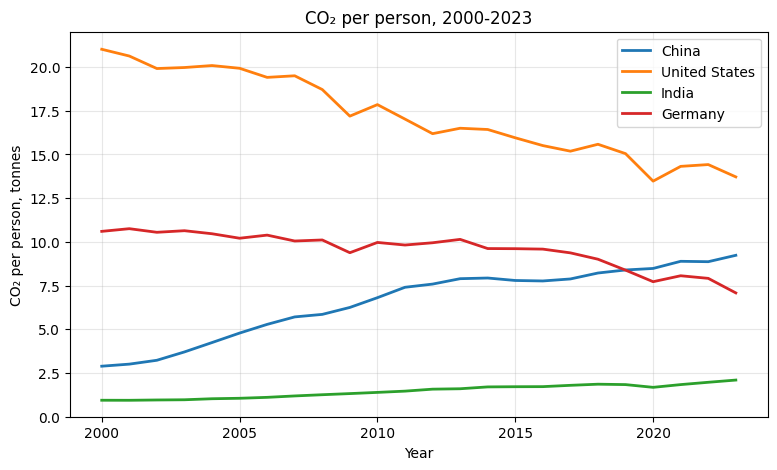

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

for country in countries:
    rows = panel[panel["country"] == country].sort_values("year")
    ax.plot(rows["year"], rows["co2_pc"], label=country, linewidth=2)

ax.set_xlabel("Year")
ax.set_ylabel("CO₂ per person, tonnes")
ax.set_title("CO₂ per person, 2000-2023")
ax.set_ylim(0, None)
ax.legend()
ax.grid(True, alpha=0.3);

### Which of the three, and for what?

They answer three different questions, and only the last two are close.

| Figure | The question it answers | Use it when |
|---|---|---|
| Seven separate files | *What did each of these look like?* | Each figure has its own destination — one per slide, one per section, one per report |
| A grid of panels | *What did each of these look like, side by side?* | There are too many series to overlay, or the shapes matter more than the levels |
| One set of axes | *How do these compare?* | The comparison **is** the point |

**Here, the single set of axes.** Four lines is well within what one chart can carry, the question is a
comparison, and the crossing of the American and Chinese lines — the single most interesting thing in
the data — is visible in the overlay and invisible in every other version, because it happens between
two panels.

The grid earns its place at about eight or more series, where an overlay becomes a bowl of spaghetti.
The seven separate files earn theirs when the figures are not going to be looked at together at all.

> 💡 **Tip:** The number of series is the wrong thing to decide on. Ask whether a reader is meant to
compare them. If yes, one set of axes, until it becomes unreadable. If no, panels or separate files.

### Things worth noticing

- **`plt.close(fig)` inside a saving loop.** The single most useful line in this notebook, and the one
  nobody writes until the day the kernel gets slow.
- **Axis labels on a grid go on the outside panels only.** With `sharex` and `sharey`, the inner ticks
  are hidden anyway, and labeling all four is noise. `axes[1, 0]` and `axes[1, 1]` are the bottom row;
  `axes[0, 0]` and `axes[1, 0]` are the left column.
- **`zip(axes.flatten(), countries)`** works for any grid size, so switching to a 1×4 or a 3×3 is a
  change to one line.
- **`os.listdir(".")` checks the result rather than assuming it.** The loop *should* have written seven
  files; counting them is how you find out that two regions collapsed to the same name.

### What this notebook does NOT do

- **It never deletes the files it wrote.** Run it twice with a different `to_file_name` and you have
  fourteen files, seven of them stale, and nothing distinguishes them. Writing into a folder your code
  clears first is the usual answer.
- **The four countries are hard-coded**, so this is a script rather than a tool. The lecture's
  `plot_region` is the shape that fixes it, and combining the two — a function that takes a list of
  countries and returns a grid — is the version worth writing.
- **`to_file_name` can silently collide.** Two different regions could map to the same stem, and the
  second would overwrite the first with no error at all. The count in the last cell is the only thing
  standing between that and going unnoticed.